# Visualizaciones con Seaborn usando `bank_transactions.csv`

En este notebook trabajaremos con un dataset de **transacciones bancarias**.

La idea es que cada visualización responda a una **pregunta específica**.  

## Columnas del dataset

- `transaction_id`
- `transaction_date`
- `customer_id`
- `segment`
- `city_client`
- `age_client`
- `transaction_type`
- `category`
- `amount`
- `merchant`
- `destination_customer`
- `balance_before`
- `balance_after`


## 1. Cargar librerías y dataset

### Instrucciones

1. Importa `pandas`, `matplotlib.pyplot` y `seaborn`
2. Carga `bank_transactions.csv`
3. Convierte la columna de fecha a formato datetime
4. Revisa las primeras filas


In [1]:
#!pip install fastparquet

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 4)

#Usar Parquet en lugar de CSV es superior para grandes volúmenes de datos debido a su estructura columnar, 
# que permite una compresión mucho más eficiente (reduciendo espacio en disco hasta un 75% o más) 
# y consultas más rápidas
df = pd.read_parquet("https://mysiterobert.s3.us-east-1.amazonaws.com/Dataframes/bank_transactions.parquet")
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

print(df.shape)
df.head()


(3996538, 13)


,transaction_id,transaction_date,customer_id,segment,city_client,age_client,transaction_type,category,amount,merchant,destination_customer,balance_before,balance_after
1239448,1239449,2025-12-01,16184,Premium,Ambato,34,Credito,Nómina,20.03,Fybeca,NaN,1621.101451,1641.131451
681067,681068,2025-12-01,8929,Profesional,Quito,43,Debito,Retiro ATM,17.49,Primax,NaN,1765.066062,1747.576062
826627,826628,2025-12-01,10856,Empresarial,Machala,44,Credito,Nómina,25.42,Netflix,NaN,202.830000,228.250000
1848642,1848643,2025-12-01,24111,Profesional,Cuenca,20,Credito,Depósito,11.73,Mi Comisariato,NaN,1553.803368,1565.533368
1933243,1933244,2025-12-01,25217,Estudiante,Machala,26,Debito,Pago servicios,24.62,Spotify,NaN,2134.225845,2109.605845


## 2. ¿Cómo se distribuyen los montos de las transacciones?

Aquí estamos analizando una variable **numérica** a nivel de transacción: `amount`.

### Gráfica sugerida
**Histplot**

### Preguntas guía

- ¿La mayoría de transacciones son pequeñas o grandes?
- ¿La distribución parece sesgada?
- ¿Se observa una cola larga?


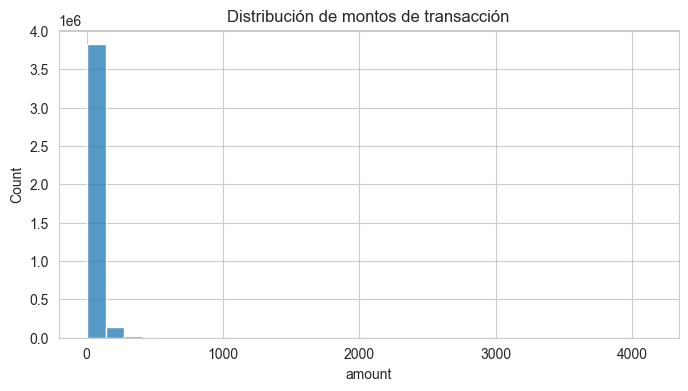

In [3]:
sns.histplot(data=df, x="amount", bins=30)
plt.title("Distribución de montos de transacción")
plt.show()


## 3. ¿Existen valores extremos en los montos de transacción?

Seguimos trabajando a nivel de transacción, pero ahora queremos resumir la distribución y detectar posibles outliers.

### Gráfica sugerida
**Boxplot**


<Axes: xlabel='amount', ylabel='Count'>

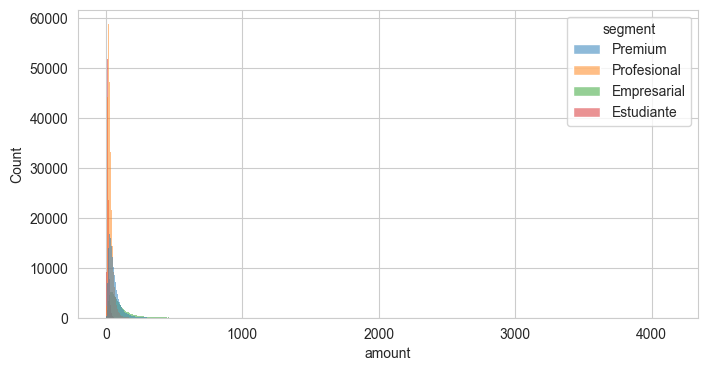

In [43]:
sns.histplot(data=df, x="amount", hue = "segment")

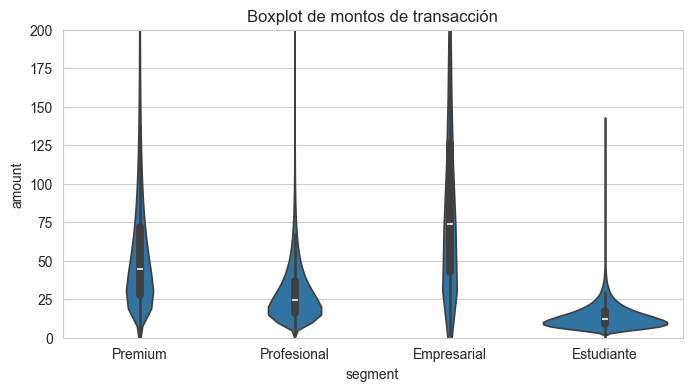

In [ ]:
sns.violinplot(data=df, y="amount", x = "segment")
plt.title("Boxplot de montos de transacción")
plt.ylim([0,200])
plt.show()



## 4. ¿Qué tan diferentes son los montos de transacción entre segmentos?

Aquí comparamos una variable numérica (`amount`) entre grupos (`segment`).

### Gráfica sugerida
**Boxplot por categoría**


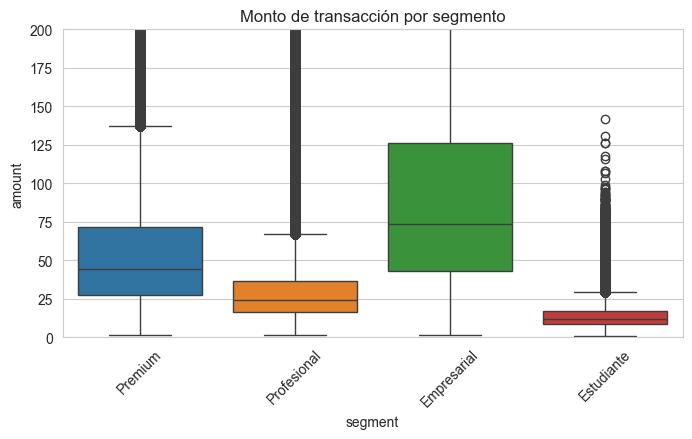

In [5]:
sns.boxplot(data=df, x="segment", y="amount", hue="segment")
plt.title("Monto de transacción por segmento")
plt.xticks(rotation=45)
plt.ylim([0,200])
plt.show()


## 5. ¿Cómo se distribuyen los segmentos entre los clientes?

Esta pregunta es a nivel de **cliente**, no de transacción.  
Por eso primero construiremos un dataset con **un registro por cliente**.

### Gráfica sugerida
**Countplot**


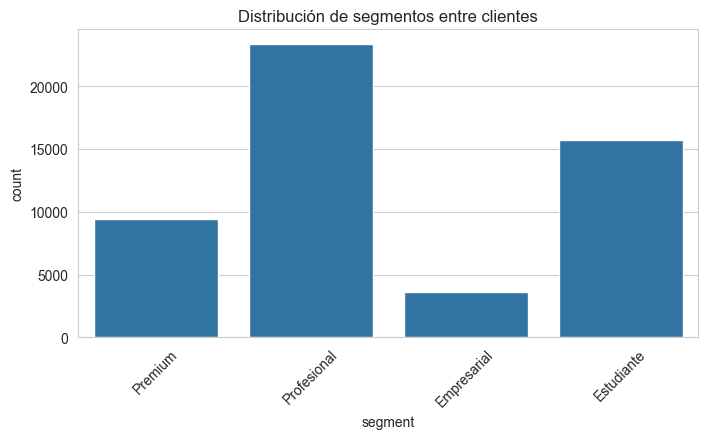

In [6]:
df_clients = df[["customer_id", "segment", "city_client", "age_client"]].drop_duplicates()

sns.countplot(data=df_clients, x="segment")
plt.title("Distribución de segmentos entre clientes")
plt.xticks(rotation=45)
plt.show()


## 6. ¿Cómo se distribuyen los segmentos entre los clientes? (barplot)

Responderemos la misma pregunta, pero resumiendo primero los datos.

### Gráfica sugerida
**Barplot**


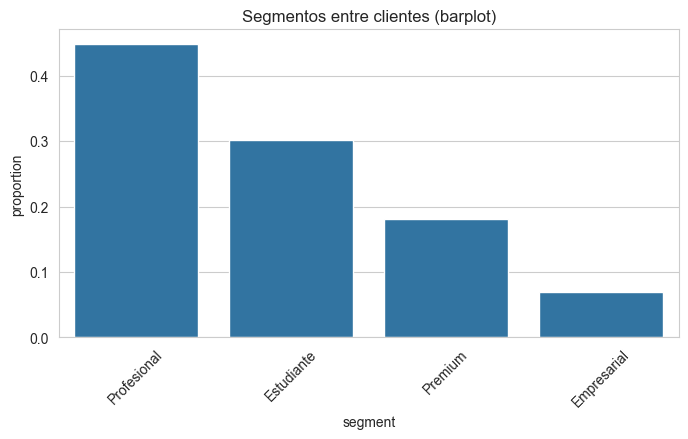

In [7]:
segment_counts = df_clients["segment"].value_counts(normalize=True)

sns.barplot(segment_counts)
plt.title("Segmentos entre clientes (barplot)")
plt.xticks(rotation=45)
plt.show()


## 7. ¿Cuál es la proporción de segmentos entre los clientes?

Seguimos con la misma pregunta, pero ahora usando una visualización de proporciones.

### Gráfica sugerida
**Pie chart**


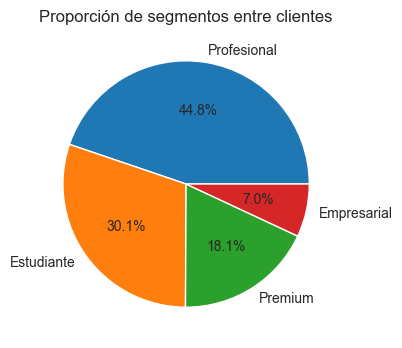

In [8]:
segment_counts = df_clients["segment"].value_counts()

plt.pie(
    segment_counts.values,
    labels=segment_counts.index,
    autopct="%1.1f%%"
)
plt.title("Proporción de segmentos entre clientes")
plt.show()


## 8. ¿Qué tipo de transacción ocurre con mayor frecuencia?

Aquí la unidad de análisis vuelve a ser la **transacción**.

### Gráfica sugerida
**Countplot**


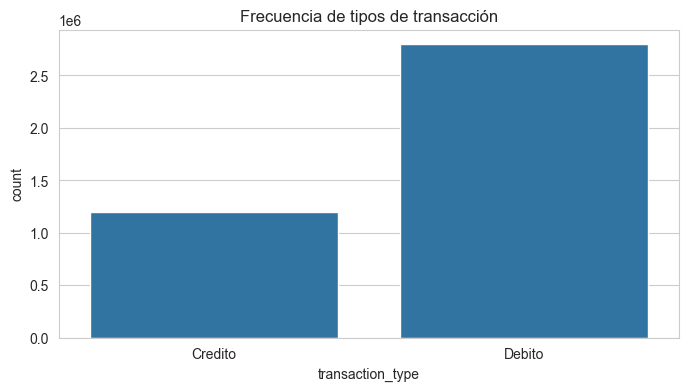

In [9]:
sns.countplot(data=df, x="transaction_type")
plt.title("Frecuencia de tipos de transacción")
plt.show()


## 9. ¿Qué categoría de transacción ocurre con mayor frecuencia?

Seguimos a nivel de transacción.

### Gráfica sugerida
**Countplot**


In [10]:
%matplotlib notebook
sns.countplot(
    data=df,
    y="category",
    order=df["category"].value_counts().index
)
plt.title("Frecuencia de categorías de transacción")
plt.show()


<IPython.core.display.Javascript object>

## 10. ¿Existe relación entre la edad del cliente y el monto promedio de sus transacciones?

Esta pregunta ya no debe hacerse directamente con el dataframe de transacciones, porque un cliente puede aparecer muchas veces.  
Primero construiremos un dataset agregado por cliente.

### Gráfica sugerida
**Scatterplot**


In [11]:
df_client_summary = (
    df.groupby("customer_id", as_index=False)
      .agg(
          age_client=("age_client", "first"),
          segment=("segment", "first"),
          avg_amount=("amount", "mean"),
          n_transactions=("transaction_id", "count")
      )
)

df_client_summary.head()

,customer_id,age_client,segment,avg_amount,n_transactions
0,0,39,Profesional,30.790260,77
1,1,41,Estudiante,13.927895,57
2,2,32,Profesional,29.645507,69
3,3,50,Premium,62.278667,90
4,4,30,Profesional,30.743793,87


In [12]:

sns.scatterplot(data=df_client_summary, x="age_client", y="avg_amount")
plt.title("Edad del cliente vs monto promedio de transacción")
plt.show()


## 11. ¿Los clientes con más transacciones también tienen montos promedio más altos?

Ahora usaremos el mismo dataset agregado por cliente.

### Gráfica sugerida
**Scatterplot con hue**


In [13]:
df_client_summary = (
    df
    .groupby("customer_id", as_index=False)
    .agg(
        age_client=("age_client", "first"),
        segment=("segment", "first"),
        city_client=("city_client", "first"),
        avg_amount=("amount", "mean"),
        total_amount=("amount", "sum"),
        n_transactions=("transaction_id", "count"),
        avg_balance_before=("balance_before", "mean")
    )
)

df_client_summary.head()

,customer_id,age_client,segment,city_client,avg_amount,total_amount,n_transactions,avg_balance_before
0,0,39,Profesional,Guayaquil,30.790260,2370.85,77,719.138847
1,1,41,Estudiante,Quito,13.927895,793.89,57,4906.684622
2,2,32,Profesional,Machala,29.645507,2045.54,69,665.861137
3,3,50,Premium,Guayaquil,62.278667,5605.08,90,1617.903082
4,4,30,Profesional,Guayaquil,30.743793,2674.71,87,1184.081925


In [14]:
sns.scatterplot(
    data=df_client_summary,
    x="n_transactions",
    y="avg_amount",
    hue="segment"
)
plt.title("Número de transacciones vs monto promedio")
plt.show()


## 12. ¿Cuál es la cantidad de retiros a través del tiempo?

Primero filtramos la categoría asociada a retiros y luego contamos cuántas transacciones hubo por fecha.

### Gráfica sugerida
**Lineplot**


In [33]:
retiros

,transaction_id,transaction_date,customer_id,segment,city_client,age_client,transaction_type,category,amount,merchant,destination_customer,balance_before,balance_after,date
681067,681068,2025-12-01 00:00:00,8929,Profesional,Quito,43,Debito,Retiro ATM,17.49,Primax,NaN,1765.066062,1747.576062,2025-12-01
963556,963557,2025-12-01 00:00:00,12635,Empresarial,Cuenca,32,Debito,Retiro ATM,133.89,Mi Comisariato,NaN,2454.890097,2321.000097,2025-12-01
1686241,1686242,2025-12-01 00:00:00,21973,Estudiante,Machala,33,Debito,Retiro ATM,12.96,Mi Comisariato,NaN,402.351369,389.391369,2025-12-01
1270465,1270466,2025-12-01 00:00:00,16589,Estudiante,Ambato,44,Debito,Retiro ATM,9.83,Fybeca,NaN,5200.568349,5190.738349,2025-12-01
1442765,1442766,2025-12-01 00:00:00,18804,Empresarial,Guayaquil,31,Debito,Retiro ATM,113.62,Amazon,NaN,143.590000,29.970000,2025-12-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2719669,2719670,2026-03-01 23:00:00,35486,Profesional,Ambato,33,Debito,Retiro ATM,4.44,Mi Comisariato,NaN,140.461682,136.021682,2026-03-01
1662842,1662843,2026-03-01 23:00:00,21667,Empresarial,Manta,32,Debito,Retiro ATM,89.61,Fybeca,NaN,35.560000,0.000000,2026-03-01
450355,450356,2026-03-01 23:00:00,5895,Premium,Ambato,19,Debito,Retiro ATM,47.87,Primax,NaN,4374.822434,4326.952434,2026-03-01
1256062,1256063,2026-03-01 23:00:00,16408,Premium,Cuenca,37,Debito,Retiro ATM,39.34,Spotify,NaN,61.480000,22.140000,2026-03-01


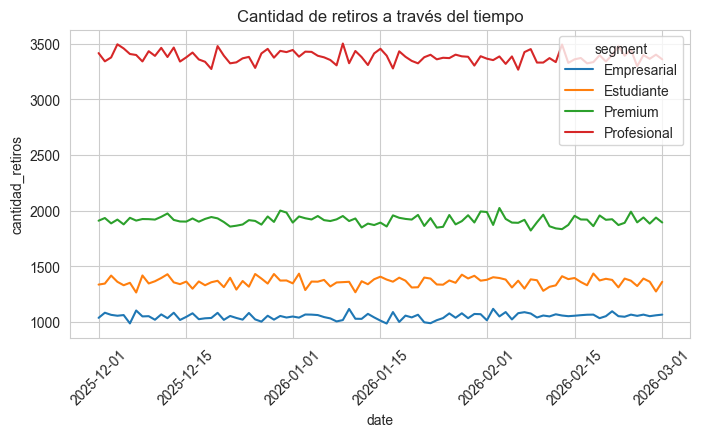

In [35]:
retiros = df[df["category"] == "Retiro ATM"].copy()
retiros["date"] = retiros["transaction_date"].dt.date

retiros_time = (
    retiros.groupby(["date", "segment"])
           .size()
           .reset_index(name="cantidad_retiros")
)

sns.lineplot(data=retiros_time, x="date", y="cantidad_retiros", hue = "segment")
plt.title("Cantidad de retiros a través del tiempo")
plt.xticks(rotation=45)
plt.show()


## 13. ¿Cómo evoluciona la cantidad diaria de transacciones según el tipo de transacción?

Ahora compararemos varias líneas en el tiempo.

### Gráfica sugerida
**Lineplot con hue**


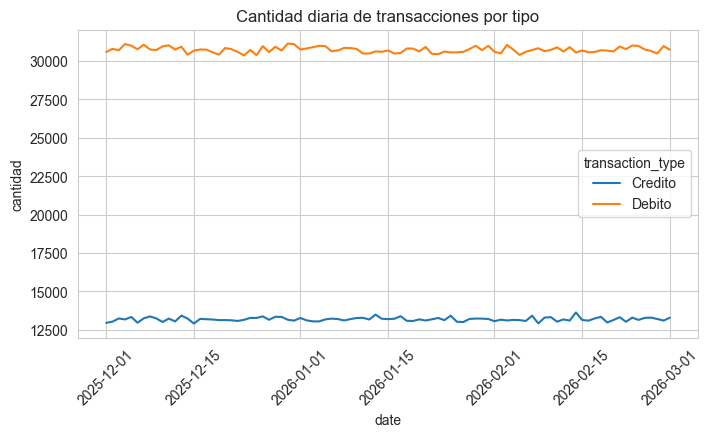

In [16]:
df["date"] = df["transaction_date"].dt.date

tx_time_type = (
    df.groupby(["date", "transaction_type"])
      .size()
      .reset_index(name="cantidad")
)

sns.lineplot(data=tx_time_type, x="date", y="cantidad", hue="transaction_type")
plt.title("Cantidad diaria de transacciones por tipo")
plt.xticks(rotation=45)
plt.show()


## 14. ¿Qué ciudad tiene el mayor monto promedio por transacción?

Esta pregunta se responde agregando a nivel de ciudad.

### Gráfica sugerida
**Barplot**


In [37]:
city_amount


,city_client,amount
0,Ambato,43.922648
5,Quito,43.458751
1,Cuenca,43.377206
3,Machala,43.093185
2,Guayaquil,43.033703
4,Manta,42.959020


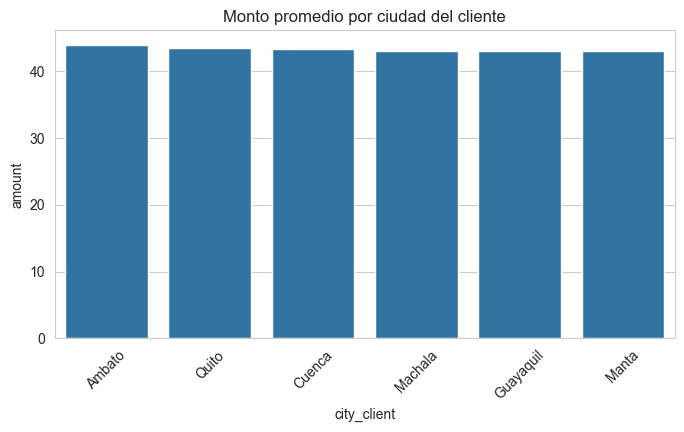

In [17]:
city_amount = (
    df.groupby("city_client", as_index=False)["amount"]
      .mean()
      .sort_values("amount", ascending=False)
)

sns.barplot(data=city_amount, x="city_client", y="amount")
plt.title("Monto promedio por ciudad del cliente")
plt.xticks(rotation=45)
plt.show()


## 15. ¿Qué ciudad tiene el mayor monto promedio por transacción, separado por segmento?

Ahora añadimos un segundo grupo en la comparación.

### Gráfica sugerida
**Barplot con hue**


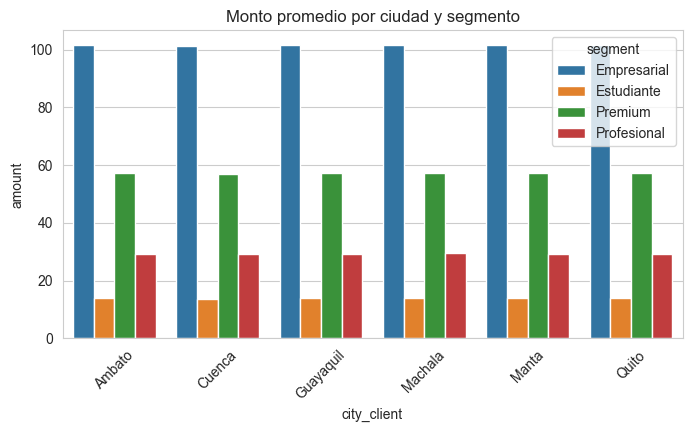

In [18]:
city_amount_hue = (
    df.groupby(["city_client", "segment"], as_index=False)["amount"]
      .mean()
)

sns.barplot(data=city_amount_hue, x="city_client", y="amount", hue="segment")
plt.title("Monto promedio por ciudad y segmento")
plt.xticks(rotation=45)
plt.show()


## 16. ¿Cuántas transacciones hay por categoría? (con etiquetas)

En algunos casos puede ser útil mostrar el valor exacto encima de cada barra.

### Gráfica sugerida
**Barplot con etiquetas**


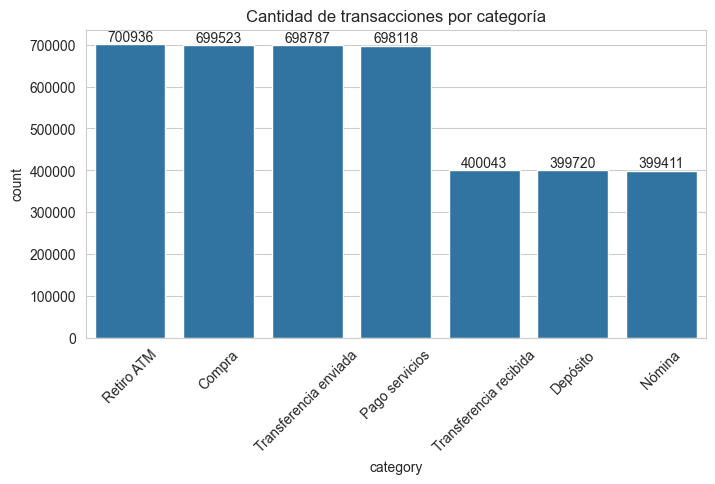

In [19]:
cat_counts = (
    df["category"]
      .value_counts()
      .reset_index()
)

cat_counts.columns = ["category", "count"]

ax = sns.barplot(data=cat_counts, x="category", y="count")
plt.title("Cantidad de transacciones por categoría")
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.show()


## 17. ¿Cómo se relacionan las variables numéricas del dataset?

Aquí construiremos un heatmap de correlación usando variables numéricas.

### Gráfica sugerida
**Heatmap**


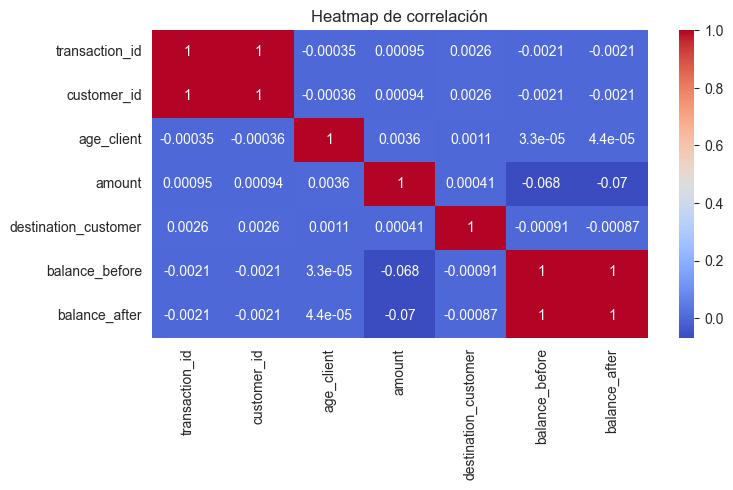

In [20]:
corr = df.select_dtypes(include="number").corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Heatmap de correlación")
plt.show()
